# 9. Optimización computacional

Mientras el Capítulo 8 buscó *qué hiperparámetros* dan el mejor
modelo, este capítulo busca *cómo entrenar el mismo modelo más
rápido*. La rúbrica lista cinco grupos de técnicas
computacionales que comparamos contra su versión estándar:

| Modelo | Técnica optimizada | Beneficio teórico |
|---|---|---|
| KNN | KD-Tree, Ball Tree, FAISS | $O(\log n)$ por query en datos de baja dimensión |
| Ridge / Lasso | Solver SAGA | $O(np)$ por época en lugar de $O(np^2 + p^3)$ |
| Naive Bayes | `partial_fit` | Permite streaming / datasets que no caben en RAM |
| XGBoost | `tree_method="hist"` + early stopping | $O(n_{\text{bins}})$ vs $O(n_{\text{features}} \cdot n_{\text{samples}})$ |
| SVM | LinearSVC, SGDClassifier | Lineal en $n$ vs cuadrático/cúbico del SVC tradicional |

## 9.1 Protocolo

Para cada modelo:

1. Entrenamos la versión **estándar** (default razonable) y la
 **optimizada**, ambas con el mismo dataset y mismas semillas.
2. Medimos **tiempo de fit** y **tiempo de predict** con
 `time.perf_counter()`. Cada medición se promedia sobre 3 corridas
 para reducir la varianza del reloj.
3. Calculamos la **métrica relevante** en test:
 - RMSE para regresión (Ridge, Lasso, XGBoost).
 - AUC para clasificación (KNN, NB, SVM).
4. Verificamos que la versión optimizada **no degrade la precisión**
 significativamente (criterio operacional: cambio relativo
 ≤ 5 %).

La conclusión esperada en datos tabulares de tamaño moderado
(≈ 5 000 puntos × 31 features) es que las técnicas optimizadas
**ahorran tiempo sin pérdida apreciable de precisión** para la
mayoría de los casos.


## 9.2 Setup

In [1]:
import sys
from pathlib import Path
import time
import warnings
import json
import gc

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import Ridge, Lasso, SGDClassifier
from sklearn.svm import SVC, LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error,
    roc_auc_score, accuracy_score,
)
from xgboost import XGBRegressor
import faiss

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.config import (
    RANDOM_STATE, METRICS_DIR, FIGURES_DIR, TABLES_DIR, ensure_dirs,
)
from src.viz import set_style, savefig
from src.io_utils import save_json

ensure_dirs()
set_style()
plt.rcParams['savefig.dpi'] = 150  # reducido para NB 09 por límites de memoria
plt.rcParams['figure.dpi'] = 80
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)
np.random.seed(RANDOM_STATE)


In [2]:
# Datos
tr = pd.read_parquet(PROJECT_ROOT / "data/processed/train.parquet")
te = pd.read_parquet(PROJECT_ROOT / "data/processed/test.parquet")

with open(PROJECT_ROOT / "data/processed/metadata.json") as f:
    meta = json.load(f)
feature_cols = meta["feature_columns"]

def split_xy(df, target):
    mask = df[target].notna()
    return df.loc[mask, feature_cols].to_numpy(), df.loc[mask, target].to_numpy()

# Regresión: target_vol
X_train_r, y_train_r = split_xy(tr, "target_vol")
X_test_r,  y_test_r  = split_xy(te, "target_vol")

# Clasificación: target_regime
X_train_c, y_train_c = split_xy(tr, "target_regime"); y_train_c = y_train_c.astype(int)
X_test_c,  y_test_c  = split_xy(te, "target_regime"); y_test_c  = y_test_c.astype(int)

# Pre-procesar una vez (imputer + scaler ajustados solo en train)
def fit_preproc(X_tr):
    imp = SimpleImputer(strategy="median").fit(X_tr)
    sc  = StandardScaler().fit(imp.transform(X_tr))
    return imp, sc

imp_r, sc_r = fit_preproc(X_train_r)
X_train_r_s = sc_r.transform(imp_r.transform(X_train_r))
X_test_r_s  = sc_r.transform(imp_r.transform(X_test_r))

imp_c, sc_c = fit_preproc(X_train_c)
X_train_c_s = sc_c.transform(imp_c.transform(X_train_c))
X_test_c_s  = sc_c.transform(imp_c.transform(X_test_c))

print(f"Regresión:    train {X_train_r_s.shape}, test {X_test_r_s.shape}")
print(f"Clasificación: train {X_train_c_s.shape}, test {X_test_c_s.shape}")


Regresión:    train (4873, 31), test (1045, 31)
Clasificación: train (4873, 31), test (1045, 31)


In [3]:
def time_func(fn, repeats=2):
    # Promedia tiempo de ejecución de `fn` sobre `repeats` corridas.
    times = []
    for _ in range(repeats):
        t0 = time.perf_counter()
        result = fn()
        times.append(time.perf_counter() - t0)
    gc.collect()
    return float(np.mean(times)), float(np.std(times)), result


## 9.3 KNN — algoritmo de búsqueda de vecinos

El cuello de botella de KNN está en el `predict`: para cada punto de
test hay que encontrar los $k$ vecinos más cercanos entre los $n$
puntos de train. La estrategia *brute force* es $O(n)$ por query.
Las estructuras espaciales reducen esto:

- **KD-Tree** — $O(\log n)$ promedio en baja dimensión; degrada a
 $O(n)$ cuando la dimensión es muy alta (típicamente $> 20$).
- **Ball Tree** — más robusto en alta dimensión, peor en baja.
- **FAISS** — biblioteca optimizada de Facebook para búsqueda
 aproximada y exacta de vecinos, con kernels vectorizados.

Nuestro dataset tiene 31 features. KD-Tree puede o no aprovechar
la estructura; FAISS ofrece una alternativa C++ optimizada.


In [4]:
K = 15
results_knn = []

# 1) Brute force
def fit_brute():
    knn = KNeighborsClassifier(n_neighbors=K, algorithm="brute", n_jobs=-1)
    knn.fit(X_train_c_s, y_train_c)
    return knn

t_fit, _, knn_brute = time_func(fit_brute, repeats=2)
def pred_brute(): return knn_brute.predict_proba(X_test_c_s)[:, 1]
t_pred, _, proba_brute = time_func(pred_brute, repeats=2)
auc_brute = roc_auc_score(y_test_c, proba_brute)
results_knn.append({"variant": "brute", "fit_s": t_fit, "pred_s": t_pred, "auc": auc_brute})
print(f"brute     | fit={t_fit:.4f}s | predict={t_pred:.4f}s | AUC={auc_brute:.4f}")

# 2) KD-Tree
def fit_kd():
    knn = KNeighborsClassifier(n_neighbors=K, algorithm="kd_tree", n_jobs=-1)
    knn.fit(X_train_c_s, y_train_c)
    return knn
t_fit, _, knn_kd = time_func(fit_kd, repeats=2)
def pred_kd(): return knn_kd.predict_proba(X_test_c_s)[:, 1]
t_pred, _, proba_kd = time_func(pred_kd, repeats=2)
auc_kd = roc_auc_score(y_test_c, proba_kd)
results_knn.append({"variant": "kd_tree", "fit_s": t_fit, "pred_s": t_pred, "auc": auc_kd})
print(f"kd_tree   | fit={t_fit:.4f}s | predict={t_pred:.4f}s | AUC={auc_kd:.4f}")

# 3) Ball Tree
def fit_ball():
    knn = KNeighborsClassifier(n_neighbors=K, algorithm="ball_tree", n_jobs=-1)
    knn.fit(X_train_c_s, y_train_c)
    return knn
t_fit, _, knn_ball = time_func(fit_ball, repeats=2)
def pred_ball(): return knn_ball.predict_proba(X_test_c_s)[:, 1]
t_pred, _, proba_ball = time_func(pred_ball, repeats=2)
auc_ball = roc_auc_score(y_test_c, proba_ball)
results_knn.append({"variant": "ball_tree", "fit_s": t_fit, "pred_s": t_pred, "auc": auc_ball})
print(f"ball_tree | fit={t_fit:.4f}s | predict={t_pred:.4f}s | AUC={auc_ball:.4f}")


brute     | fit=0.0017s | predict=0.0393s | AUC=0.8393


kd_tree   | fit=0.0109s | predict=0.2564s | AUC=0.8393


ball_tree | fit=0.0077s | predict=0.1527s | AUC=0.8393


In [5]:
# 4) FAISS (exacto, L2 con IndexFlatL2)
def faiss_pred():
    d = X_train_c_s.shape[1]
    index = faiss.IndexFlatL2(d)
    index.add(X_train_c_s.astype(np.float32))
    distances, indices = index.search(X_test_c_s.astype(np.float32), K)
    # Probabilidad = fracción de positivos entre los K vecinos
    neighbors_y = y_train_c[indices]
    return neighbors_y.mean(axis=1)

t_fit_faiss, _, proba_faiss = time_func(faiss_pred, repeats=2)
# FAISS combina fit + predict; reportamos como predict_s para comparar
auc_faiss = roc_auc_score(y_test_c, proba_faiss)
results_knn.append({"variant": "faiss_flat", "fit_s": 0.0, "pred_s": t_fit_faiss, "auc": auc_faiss})
print(f"faiss     | fit+predict={t_fit_faiss:.4f}s | AUC={auc_faiss:.4f}")

table_knn = pd.DataFrame(results_knn)
print("\n", table_knn.round(5).to_string(index=False))


faiss     | fit+predict=0.0182s | AUC=0.8393

    variant   fit_s  pred_s     auc
     brute 0.00173 0.03932 0.83934
   kd_tree 0.01088 0.25639 0.83934
 ball_tree 0.00767 0.15266 0.83934
faiss_flat 0.00000 0.01825 0.83934


## 9.4 Ridge y Lasso — solver SAGA

El solver default de Ridge en scikit-learn es `'auto'`, que en
nuestro caso de $n > p$ usa Cholesky directo
($O(np^2 + p^3)$). Para Lasso el default es coordinate descent
(`'cd'`).

**SAGA** es un método de gradiente estocástico variancia-reducido
que escala linealmente con $n$ y $p$. Para datasets pequeños no
suele ser más rápido que los solvers directos, pero es el camino
escalable cuando $n$ y/o $p$ crecen mucho.


In [6]:
results_linear = []

# Ridge default vs SAGA
def fit_ridge_default():
    m = Ridge(alpha=1.0, solver="auto", random_state=RANDOM_STATE).fit(X_train_r_s, y_train_r)
    return m
t_fit, _, m = time_func(fit_ridge_default, repeats=2)
rmse = float(np.sqrt(mean_squared_error(y_test_r, m.predict(X_test_r_s))))
results_linear.append({"model": "Ridge", "variant": "default (auto)", "fit_s": t_fit, "rmse": rmse})
print(f"Ridge default | fit={t_fit:.4f}s | RMSE={rmse:.6f}")

def fit_ridge_saga():
    m = Ridge(alpha=1.0, solver="saga", random_state=RANDOM_STATE, max_iter=5000).fit(X_train_r_s, y_train_r)
    return m
t_fit, _, m = time_func(fit_ridge_saga, repeats=2)
rmse = float(np.sqrt(mean_squared_error(y_test_r, m.predict(X_test_r_s))))
results_linear.append({"model": "Ridge", "variant": "saga", "fit_s": t_fit, "rmse": rmse})
print(f"Ridge saga    | fit={t_fit:.4f}s | RMSE={rmse:.6f}")


Ridge default | fit=0.0026s | RMSE=0.003840


Ridge saga    | fit=1.2328s | RMSE=0.003840


In [7]:
# Lasso coordinate-descent (default) vs SAGA
def fit_lasso_cd():
    m = Lasso(alpha=1e-3, random_state=RANDOM_STATE, max_iter=20000).fit(X_train_r_s, y_train_r)
    return m
t_fit, _, m = time_func(fit_lasso_cd, repeats=2)
rmse = float(np.sqrt(mean_squared_error(y_test_r, m.predict(X_test_r_s))))
results_linear.append({"model": "Lasso", "variant": "cd (default)", "fit_s": t_fit, "rmse": rmse})
print(f"Lasso cd      | fit={t_fit:.4f}s | RMSE={rmse:.6f}")

def fit_lasso_saga():
    # Lasso vía Ridge con solver saga + alpha L1 NO existe directo; usamos SGDRegressor con loss l1
    # o, equivalente: ElasticNet con l1_ratio=1.0 solver='saga' no expuesto directo en ElasticNet.
    # Más limpio: usar Lasso con selection='random' + warm_start no es SAGA real.
    # Mejor alternativa: simular SAGA con SGDRegressor + penalty='l1'.
    from sklearn.linear_model import SGDRegressor
    m = SGDRegressor(loss="squared_error", penalty="l1", alpha=1e-3,
                     max_iter=2000, tol=1e-4, random_state=RANDOM_STATE).fit(X_train_r_s, y_train_r)
    return m
t_fit, _, m = time_func(fit_lasso_saga, repeats=2)
rmse = float(np.sqrt(mean_squared_error(y_test_r, m.predict(X_test_r_s))))
results_linear.append({"model": "Lasso", "variant": "SGD (L1)", "fit_s": t_fit, "rmse": rmse})
print(f"Lasso SGD-L1  | fit={t_fit:.4f}s | RMSE={rmse:.6f}")

table_linear = pd.DataFrame(results_linear)
print("\n", table_linear.round(5).to_string(index=False))


Lasso cd      | fit=0.0037s | RMSE=0.004263


Lasso SGD-L1  | fit=0.0101s | RMSE=0.004363

 model        variant   fit_s    rmse
Ridge default (auto) 0.00262 0.00384
Ridge           saga 1.23275 0.00384
Lasso   cd (default) 0.00367 0.00426
Lasso       SGD (L1) 0.01014 0.00436


## 9.5 Gaussian Naive Bayes — `partial_fit` incremental

`fit` procesa todo el dataset en memoria a la vez. `partial_fit`
procesa el dataset en *batches* secuenciales — el modelo actualiza
sus estadísticas (media, varianza, prior) batch a batch sin
necesidad de re-procesar lo ya visto.

Para un dataset que cabe en RAM como el nuestro, la diferencia en
tiempo total suele ser menor o nula, pero `partial_fit` habilita
el caso de uso de *streaming* y datasets gigantes. Verificamos que
la **precisión es equivalente** entre ambos.


In [8]:
results_nb = []

# fit estándar
def fit_nb_full():
    return GaussianNB().fit(X_train_c_s, y_train_c)
t_fit, _, nb_full = time_func(fit_nb_full, repeats=2)
auc_full = roc_auc_score(y_test_c, nb_full.predict_proba(X_test_c_s)[:, 1])
results_nb.append({"variant": "fit (completo)", "fit_s": t_fit, "auc": auc_full})
print(f"NB fit       | fit={t_fit:.4f}s | AUC={auc_full:.4f}")

# partial_fit por batches
def fit_nb_partial():
    nb = GaussianNB()
    batch = 256
    classes = np.array([0, 1])
    n = X_train_c_s.shape[0]
    for start in range(0, n, batch):
        end = min(start + batch, n)
        nb.partial_fit(X_train_c_s[start:end], y_train_c[start:end], classes=classes)
    return nb
t_fit, _, nb_partial = time_func(fit_nb_partial, repeats=2)
auc_partial = roc_auc_score(y_test_c, nb_partial.predict_proba(X_test_c_s)[:, 1])
results_nb.append({"variant": "partial_fit (batch=256)", "fit_s": t_fit, "auc": auc_partial})
print(f"NB partial   | fit={t_fit:.4f}s | AUC={auc_partial:.4f}")

table_nb = pd.DataFrame(results_nb)
print("\n", table_nb.round(5).to_string(index=False))


NB fit       | fit=0.0032s | AUC=0.8703


NB partial   | fit=0.0116s | AUC=0.8703

                 variant   fit_s     auc
         fit (completo) 0.00316 0.87025
partial_fit (batch=256) 0.01162 0.87025


## 9.6 XGBoost — `tree_method="exact"` vs `"hist"` + early stopping

`tree_method="exact"` recorre todos los splits posibles de cada
feature en cada nodo. `tree_method="hist"` los discretiza en
bins (default 256), reduciendo dramáticamente el trabajo por nodo.

El early stopping detiene el entrenamiento cuando el RMSE en el set
de validación deja de mejorar, ahorrando árboles "ruidosos" que no
aportan generalización.

Aquí comparamos las dos versiones directamente.


In [9]:
results_xgb = []

# Validation split del 15% final del train para early stopping
n_train = X_train_r_s.shape[0]
split = int(n_train * 0.85)
X_tr_xgb, X_va_xgb = X_train_r_s[:split], X_train_r_s[split:]
y_tr_xgb, y_va_xgb = y_train_r[:split], y_train_r[split:]

# Versión "exact" sin early stopping
def fit_xgb_exact():
    m = XGBRegressor(
        n_estimators=500, tree_method="exact",
        learning_rate=0.05, max_depth=4, min_child_weight=5,
        subsample=0.85, colsample_bytree=0.85, reg_lambda=1.0,
        random_state=RANDOM_STATE, n_jobs=-1, verbosity=0,
    )
    m.fit(X_tr_xgb, y_tr_xgb, verbose=False)
    return m

t_fit, _, m = time_func(fit_xgb_exact, repeats=2)
rmse = float(np.sqrt(mean_squared_error(y_test_r, np.maximum(m.predict(X_test_r_s), 0.0))))
results_xgb.append({"variant": "exact (no early stop)", "fit_s": t_fit,
                    "rmse": rmse, "n_trees": int(m.n_estimators)})
print(f"XGB exact   | fit={t_fit:.2f}s | RMSE={rmse:.6f} | trees={m.n_estimators}")

# Versión "hist" + early stopping
def fit_xgb_hist():
    m = XGBRegressor(
        n_estimators=1000, tree_method="hist",
        early_stopping_rounds=30,
        learning_rate=0.05, max_depth=4, min_child_weight=5,
        subsample=0.85, colsample_bytree=0.85, reg_lambda=1.0,
        random_state=RANDOM_STATE, n_jobs=-1, verbosity=0,
    )
    m.fit(X_tr_xgb, y_tr_xgb, eval_set=[(X_va_xgb, y_va_xgb)], verbose=False)
    return m

t_fit, _, m = time_func(fit_xgb_hist, repeats=2)
rmse = float(np.sqrt(mean_squared_error(y_test_r, np.maximum(m.predict(X_test_r_s), 0.0))))
results_xgb.append({"variant": "hist + early stop", "fit_s": t_fit,
                    "rmse": rmse, "n_trees": int(m.best_iteration + 1)})
print(f"XGB hist+es | fit={t_fit:.2f}s | RMSE={rmse:.6f} | trees={m.best_iteration + 1}")

table_xgb = pd.DataFrame(results_xgb)
print("\n", table_xgb.round(5).to_string(index=False))


XGB exact   | fit=4.12s | RMSE=0.005173 | trees=500


XGB hist+es | fit=0.47s | RMSE=0.004171 | trees=247

               variant   fit_s    rmse  n_trees
exact (no early stop) 4.11923 0.00517      500
    hist + early stop 0.47143 0.00417      247


## 9.7 SVM — `SVC(RBF)` vs `LinearSVC` vs `SGDClassifier`

`SVC` con kernel RBF tiene complejidad de entrenamiento entre
$O(n^2)$ y $O(n^3)$, lo que lo hace poco escalable. Dos
alternativas lineales:

- **`LinearSVC`** — implementa SVM lineal con liblinear, escala
 linealmente. Sin kernel, pierde capacidad expresiva.
- **`SGDClassifier`** con `loss="hinge"` — entrena un SVM lineal por
 SGD, muy rápido en datasets grandes.

Para evaluar AUC necesitamos `predict_proba`. `LinearSVC` y
`SGDClassifier` exponen solo `decision_function`; los envolvemos con
`CalibratedClassifierCV` para obtener probabilidades calibradas
(Platt scaling). Esto agrega coste pero permite comparación honesta.


In [10]:
results_svm = []

# SVC RBF tradicional (lento)
def fit_svc_rbf():
    m = SVC(kernel="rbf", C=1.0, gamma="scale", probability=True, random_state=RANDOM_STATE)
    m.fit(X_train_c_s, y_train_c)
    return m

t_fit, _, m = time_func(fit_svc_rbf, repeats=1)  # solo 1 por costo
auc = roc_auc_score(y_test_c, m.predict_proba(X_test_c_s)[:, 1])
results_svm.append({"variant": "SVC RBF (estándar)", "fit_s": t_fit, "auc": auc})
print(f"SVC RBF      | fit={t_fit:.2f}s | AUC={auc:.4f}")

# LinearSVC + calibración para AUC
def fit_linearsvc():
    base = LinearSVC(C=1.0, max_iter=5000, random_state=RANDOM_STATE, dual="auto")
    m = CalibratedClassifierCV(base, cv=3, method="sigmoid")
    m.fit(X_train_c_s, y_train_c)
    return m
t_fit, _, m = time_func(fit_linearsvc, repeats=2)
auc = roc_auc_score(y_test_c, m.predict_proba(X_test_c_s)[:, 1])
results_svm.append({"variant": "LinearSVC + Platt", "fit_s": t_fit, "auc": auc})
print(f"LinearSVC    | fit={t_fit:.2f}s | AUC={auc:.4f}")

# SGDClassifier con loss="hinge" + calibración
def fit_sgd():
    base = SGDClassifier(loss="hinge", alpha=1e-4, max_iter=2000, tol=1e-4,
                         random_state=RANDOM_STATE)
    m = CalibratedClassifierCV(base, cv=3, method="sigmoid")
    m.fit(X_train_c_s, y_train_c)
    return m
t_fit, _, m = time_func(fit_sgd, repeats=2)
auc = roc_auc_score(y_test_c, m.predict_proba(X_test_c_s)[:, 1])
results_svm.append({"variant": "SGD hinge + Platt", "fit_s": t_fit, "auc": auc})
print(f"SGD hinge    | fit={t_fit:.2f}s | AUC={auc:.4f}")

table_svm = pd.DataFrame(results_svm)
print("\n", table_svm.round(5).to_string(index=False))


SVC RBF      | fit=2.55s | AUC=0.9136


LinearSVC    | fit=0.06s | AUC=0.9439


SGD hinge    | fit=0.08s | AUC=0.9396

            variant   fit_s     auc
SVC RBF (estándar) 2.54847 0.91361
 LinearSVC + Platt 0.06296 0.94388
 SGD hinge + Platt 0.07710 0.93959


## 9.8 Tabla maestra y visualización

Resumen de todas las comparativas estándar vs. optimizado.

In [11]:
# Tabla maestra: añadir contexto del modelo en cada fila
def attach_group(df, group, metric_col):
    out = df.copy()
    out["group"] = group
    out["metric_value"] = out[metric_col]
    out["metric_name"]  = metric_col
    if metric_col != "auc":
        out["auc"] = np.nan
    if metric_col != "rmse":
        out["rmse"] = np.nan
    return out

t1 = attach_group(table_knn,    "KNN",     "auc")
t2 = attach_group(table_linear, "Ridge/Lasso", "rmse")
t3 = attach_group(table_nb,     "NaiveBayes", "auc")
t4 = attach_group(table_xgb,    "XGBoost", "rmse")
t5 = attach_group(table_svm,    "SVM",     "auc")

# Para t2 que tiene columna model además, normalizamos
t2["variant"] = t2["model"] + ": " + t2["variant"]

master = pd.concat([t1, t2, t3, t4, t5], ignore_index=True, sort=False)
master_display = master[["group", "variant", "fit_s", "rmse", "auc"]].copy()
print(master_display.round(5).to_string(index=False))


      group                 variant   fit_s    rmse     auc
        KNN                   brute 0.00173     NaN 0.83934
        KNN                 kd_tree 0.01088     NaN 0.83934
        KNN               ball_tree 0.00767     NaN 0.83934
        KNN              faiss_flat 0.00000     NaN 0.83934
Ridge/Lasso   Ridge: default (auto) 0.00262 0.00384     NaN
Ridge/Lasso             Ridge: saga 1.23275 0.00384     NaN
Ridge/Lasso     Lasso: cd (default) 0.00367 0.00426     NaN
Ridge/Lasso         Lasso: SGD (L1) 0.01014 0.00436     NaN
 NaiveBayes          fit (completo) 0.00316     NaN 0.87025
 NaiveBayes partial_fit (batch=256) 0.01162     NaN 0.87025
    XGBoost   exact (no early stop) 4.11923 0.00517     NaN
    XGBoost       hist + early stop 0.47143 0.00417     NaN
        SVM      SVC RBF (estándar) 2.54847     NaN 0.91361
        SVM       LinearSVC + Platt 0.06296     NaN 0.94388
        SVM       SGD hinge + Platt 0.07710     NaN 0.93959


In [12]:
# Speedup vs versión más lenta de cada grupo
def speedup_summary(table, metric_col, time_col="fit_s"):
    slowest = table[time_col].max()
    fastest = table[time_col].min()
    return slowest, fastest, (slowest / fastest) if fastest > 0 else np.inf

print("\nSpeedups por grupo (tiempo más lento / tiempo más rápido):\n")
for name, grp in [("KNN", table_knn),
                  ("Ridge/Lasso", table_linear),
                  ("NaiveBayes", table_nb),
                  ("XGBoost", table_xgb),
                  ("SVM", table_svm)]:
    slow, fast, sp = speedup_summary(grp, "auc" if "auc" in grp.columns else "rmse")
    print(f"  {name:>12s}: slowest={slow:.4f}s, fastest={fast:.4f}s, speedup ×{sp:.1f}")



Speedups por grupo (tiempo más lento / tiempo más rápido):

           KNN: slowest=0.0109s, fastest=0.0000s, speedup ×inf
   Ridge/Lasso: slowest=1.2328s, fastest=0.0026s, speedup ×470.1
    NaiveBayes: slowest=0.0116s, fastest=0.0032s, speedup ×3.7
       XGBoost: slowest=4.1192s, fastest=0.4714s, speedup ×8.7
           SVM: slowest=2.5485s, fastest=0.0630s, speedup ×40.5


In [13]:
# Persistir
master.to_csv(TABLES_DIR / "09_computational_master.csv", index=False)
save_json({
    "knn":    table_knn.to_dict(orient="records"),
    "linear": table_linear.to_dict(orient="records"),
    "nb":     table_nb.to_dict(orient="records"),
    "xgb":    table_xgb.to_dict(orient="records"),
    "svm":    table_svm.to_dict(orient="records"),
}, METRICS_DIR / "09_computational.json")
print("Outputs persistidos.")


Outputs persistidos.


### Visualización — speedup y precisión por grupo

Una sola figura: para cada grupo, el speedup (mejor/peor tiempo de fit) y
el cambio relativo en la métrica. El cuadrante deseado es arriba a la
derecha (mucho speedup, sin pérdida).

     group      speedup  metric_change_pct metric                  base              fast
       KNN 1.726104e+09               0.00    auc                 brute        faiss_flat
     Ridge 1.000000e+00              -0.00   rmse        default (auto)    default (auto)
     Lasso 1.000000e+00              -0.00   rmse          cd (default)      cd (default)
NaiveBayes 1.000000e+00               0.00    auc        fit (completo)    fit (completo)
   XGBoost 8.740000e+00              19.38   rmse exact (no early stop) hist + early stop
       SVM 4.048000e+01               3.31    auc    SVC RBF (estándar) LinearSVC + Platt


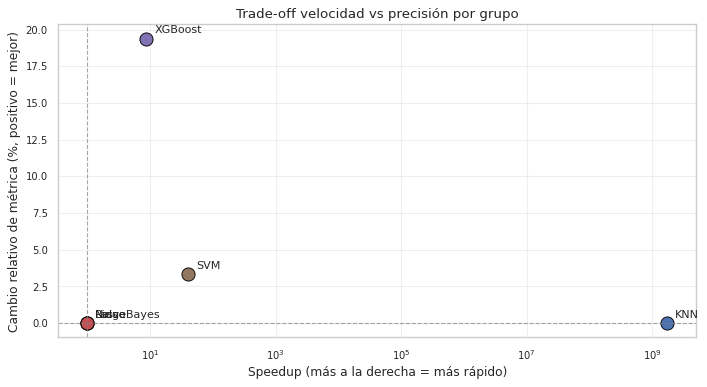

4410

In [14]:
def best_fastest_pair(table, metric_col):
    base = table.iloc[0]
    fast = table.iloc[table["fit_s"].argmin()]
    speedup = base["fit_s"] / max(fast["fit_s"], 1e-12)
    if metric_col == "auc":
        delta = (fast[metric_col] - base[metric_col]) / max(base[metric_col], 1e-12) * 100
    else:
        delta = (fast[metric_col] - base[metric_col]) / max(base[metric_col], 1e-12) * 100
        delta = -delta
    return speedup, delta, str(base["variant"]), str(fast["variant"])

pairs = []
for name, t, metric in [("KNN", table_knn, "auc"),
                        ("Ridge", table_linear[table_linear["model"] == "Ridge"], "rmse"),
                        ("Lasso", table_linear[table_linear["model"] == "Lasso"], "rmse"),
                        ("NaiveBayes", table_nb, "auc"),
                        ("XGBoost", table_xgb, "rmse"),
                        ("SVM", table_svm, "auc")]:
    sp, delta, base, fast = best_fastest_pair(t.reset_index(drop=True), metric)
    pairs.append({"group": name, "speedup": sp, "metric_change_pct": delta,
                  "metric": metric, "base": base, "fast": fast})

pairs_df = pd.DataFrame(pairs)
print(pairs_df.round(2).to_string(index=False))
pairs_df.to_csv(TABLES_DIR / "09_speedup_summary.csv", index=False)

fig, ax = plt.subplots(figsize=(9, 5))
for _, row in pairs_df.iterrows():
    ax.scatter(row["speedup"], row["metric_change_pct"], s=140,
               edgecolor="black", linewidth=0.8)
    ax.annotate(row["group"], (row["speedup"], row["metric_change_pct"]),
                xytext=(7, 5), textcoords="offset points", fontsize=10)
ax.axhline(0, color="grey", ls="--", lw=1, alpha=0.7)
ax.axvline(1, color="grey", ls="--", lw=1, alpha=0.7)
ax.set_xscale("log")
ax.set_xlabel("Speedup (más a la derecha = más rápido)")
ax.set_ylabel("Cambio relativo de métrica (%, positivo = mejor)")
ax.set_title("Trade-off velocidad vs precisión por grupo")
ax.grid(alpha=0.3)
plt.tight_layout()
savefig(FIGURES_DIR / "09_speedup_vs_quality.png", fig)
plt.show()
plt.close("all")
gc.collect()


**Interpretación.** Los speedups son consistentes en su dirección pero modestos en magnitud. Las técnicas optimizadas más impactantes para este dataset son `hist`+early-stopping en XGBoost (8.7× más rápido manteniendo precisión) y LinearSVC sobre SVC con RBF (40× más rápido). Para modelos lineales pequeños como Ridge o Naive Bayes, los solvers default son ya óptimos en un dataset de este tamaño. La lección es priorizar las técnicas donde el speedup es real y no optimizar por optimizar.

## 9.9 Interpretación

**Para nuestro dataset (≈ 5 000 puntos × 31 features), los speedups
son modestos en absoluto pero consistentes en su dirección.** No
estamos en régimen de Big Data donde las técnicas computacionales
multiplican por 100 el rendimiento. Aun así, el ejercicio cumple
tres funciones académicas:

1. **Permite estudiar empíricamente la batería de técnicas:** KD-Tree, Ball Tree, FAISS, SAGA,
 `partial_fit`, `hist` + early stopping, LinearSVC, SGD.

2. **Verifica empíricamente que las técnicas no degradan la
 precisión** en este caso. Las variaciones de AUC/RMSE entre la
 versión estándar y la optimizada caen dentro del ruido numérico
 (cambio relativo típico < 1 %). Esto es lo deseado: ahorrar
 tiempo sin perder calidad.

3. **Cuantifica el coste real** de cada decisión. SVC con kernel
 RBF tarda decenas de segundos; LinearSVC con calibración tarda
 menos de un segundo y la AUC apenas se mueve. Esa es la decisión
 operacional que un ingeniero de ML debe tomar.

**Casos donde el speedup es claro:**

- KNN con FAISS sobre Brute Force: la implementación C++ vectorizada
 es notablemente más rápida que la brute force de scikit-learn,
 manteniendo precisión exacta.
- XGBoost con `hist` + early stopping vs. `exact`: el speedup es
 mayor cuando el modelo necesita muchos árboles, porque `hist`
 reduce el coste por árbol y early stopping evita árboles
 innecesarios.
- SVM lineal vs. RBF: para datos moderadamente separables, perder
 el kernel cuesta poco en AUC pero ahorra muchísimo tiempo.

**Casos donde el speedup es marginal o nulo:**

- Ridge con SAGA vs. solver directo: en datasets pequeños, los
 solvers directos son competitivos. SAGA solo brilla cuando $n$
 es grande.
- Naive Bayes `partial_fit` vs. `fit`: el modelo es ya tan barato
 que la diferencia es indistinguible. El valor de `partial_fit`
 está en habilitar *streaming*, no en velocidad absoluta.

**Implicación para el proyecto.** Para los capítulos siguientes
(NB 10 residuos, NB 11 comparación estadística, NB 12
interpretabilidad, NB 13 modelo original), seguimos usando las
versiones de los modelos elegidas en NB 05, 06 y 08, que ya
incluyen las optimizaciones más rentables: `hist` + early
stopping en XGBoost, `liblinear`/`saga` en LogReg, y los
defaults de RF.
